In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('placement.csv')

In [ ]:
df.shape

(100, 3)

In [ ]:
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


<Axes: xlabel='cgpa', ylabel='resume_score'>

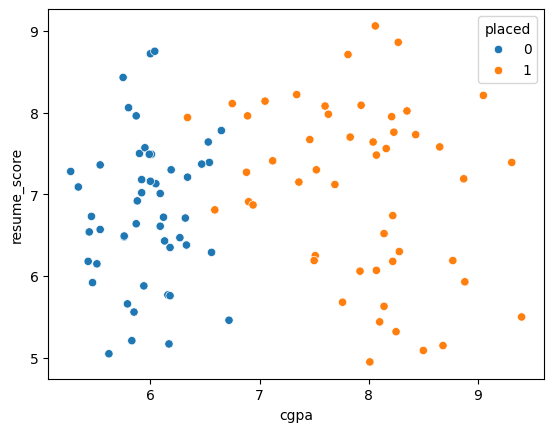

In [ ]:
sns.scatterplot(x = df['cgpa'], y = df['resume_score'], hue = df['placed'])

In [ ]:
# df.iloc[:, 0:2] -> : → take all rows, 0:2 → take columns from index 0 up to (but NOT including) 2
# df.iloc[:, -1] -> -1 → last column
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]

In [ ]:
from sklearn.linear_model import Perceptron
p = Perceptron()

In [ ]:
p.fit(X, y)

Perceptron()

In [ ]:
p.coef_

array([[ 40.26, -36.  ]])

In [ ]:
p.intercept_

array([-25.])

In [ ]:
from mlxtend.plotting import plot_decision_regions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

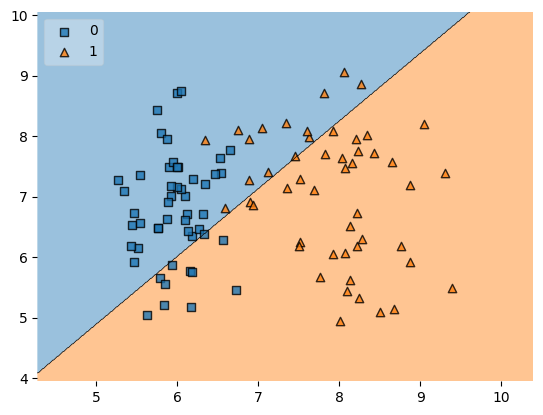

In [ ]:
# X.values -> Converts DataFrame into a NumPy array
# y.values -> Converts DataFrame into a NumPy array
# clf = classifier, p is my trained model
# 2 → nicer formatted legend

plot_decision_regions(X.values, y.values, clf = p, legend = 2)

In [ ]:
from sklearn.datasets import make_classification
import numpy as np

In [ ]:
X, y = make_classification(
    n_samples = 100,
    n_features = 2,
    n_informative = 1,
    n_redundant = 0,
    n_classes = 2,
    n_clusters_per_class = 1,
    random_state = 41,
    hypercube = False,
    class_sep = 10
)

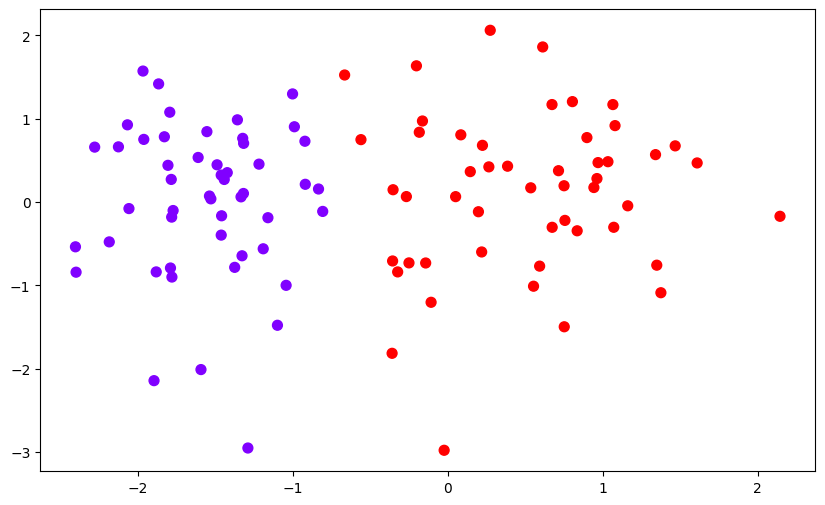

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'rainbow', s = 50)

In [ ]:
def perceptron(X, y):
  X = np.insert(X, 0, 1, axis = 1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    j = np.random.randint(0, 100)
    y_hat = step(np.dot(X[j], weights))
    weights = weights + lr * (y[j] - y_hat) * X[j]

  return weights[0], weights[1:]

In [ ]:
def step(z):
  return 1 if z > 0 else 0

In [ ]:
intercept_, coef_ = perceptron(X, y)

In [ ]:
print(intercept_)
print(coef_)

0.9
[1.39137927 0.21582937]


In [ ]:
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [ ]:
x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + b

(-3.0, 2.0)

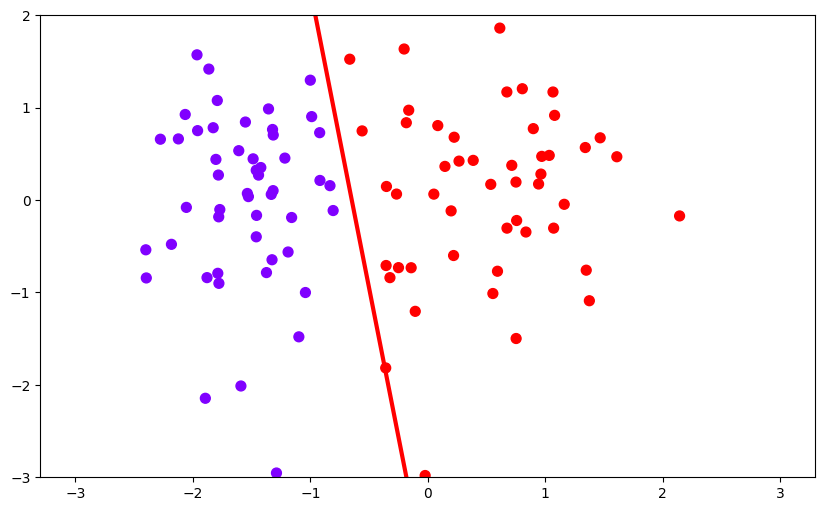

In [ ]:
plt.figure(figsize = (10, 6))
plt.plot(x_input, y_input, color = 'red', linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'rainbow', s = 50)
plt.ylim(-3, 2)